# 04 — LLTV defensibility

Does the LLTV of each market leave room for the worst collateral move its price history holds, before the protocol books bad debt? The loop reads the published `lltv_headroom` / `worst_drop` family of `outputs/market_metrics` (written hourly by the risk engine), joins it to the markets dimension and to the curators' vault allocations, and interprets. It computes no new statistic.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from myrmidons_api import OutputStore, SnapshotReader
from myrmidons_api.outputs import LIQ_CAPACITY, MARKET_METRICS

from mrsearch import read_manifest

manifest = read_manifest(Path.cwd())
print(manifest)

DATA = Path.cwd().parents[1] / "data"
r = SnapshotReader(DATA, mnemon_repo=os.environ.get("MNEMON_REPO"))
store = OutputStore(DATA)
pd.set_option("display.width", 220)

MODEL_VERSION = "api-v0.4.1+metron-v1.4.0"  # pinned: the family's only clean version
HORIZONS = (1, 6, 24)
CHAINS = {1: "Ethereum", 8453: "Base", 999: "HyperEVM"}

slim = ["as_of", "chain_id", "market_id", "metric", "value", "status", "model_version"]
mm = store.read(MARKET_METRICS, columns=slim)
fam = mm[
    mm.metric.str.startswith(("lltv_headroom_", "worst_drop_"))
    & (mm.model_version == MODEL_VERSION)
]
AS_OF = pd.Timestamp(fam.as_of.max()).tz_convert("UTC")
n_cycles = mm[mm.metric.str.startswith("lltv_headroom_")].as_of.nunique()
fam = fam[fam.as_of == fam.as_of.max()].copy()
print(
    f"{len(mm)} market_metrics rows; family cycles {n_cycles}; "
    f"cross-section cycle {AS_OF} with {len(fam)} rows"
)

# params/input_window only for the rows of this cross-section (the JSON columns are heavy)
meta = store.read_matching(MARKET_METRICS, fam, ["params", "input_window"])
fam = fam.merge(meta, on=MARKET_METRICS.keys, how="left")

sym = r.sql(
    "SELECT chain_id, market_id, collateral_symbol || '/' || loan_symbol AS pair, "
    "collateral_symbol, loan_symbol, collateral_token, loan_token, loan_decimals, listed, "
    "lltv::DOUBLE/1e18 AS lltv FROM markets WHERE collateral_token IS NOT NULL"
)

# wide frame: one row per market — statuses first (every market has them), values where
# they exist, the 24h row's params. pivot_table would drop a market whose values are all null.
key = ["chain_id", "market_id"]
st = fam.pivot(index=key, columns="metric", values="status").add_prefix("status_")
val = fam.pivot(index=key, columns="metric", values="value")
p24 = fam[fam.metric == "lltv_headroom_24h"].set_index(key).params.map(json.loads)
params = pd.DataFrame(
    {
        "buffer": p24.map(lambda p: p["buffer"]),
        "lif": p24.map(lambda p: p["lif"]),
        "coverage": p24.map(lambda p: p["coverage"]),
        "history_d": p24.map(lambda p: p["history_d"]),
        "spikes_dropped": p24.map(lambda p: p["spikes_dropped"]),
        "costs": p24.map(lambda p: p["costs"]),
    }
)
h = st.join(val).join(params).reset_index().merge(sym, on=key, how="left")
h["chain"] = h.chain_id.map(CHAINS).fillna(h.chain_id.astype(str))

# outstanding borrow at the nearest liq_capacity cycle, for weighting
cap = store.read(
    LIQ_CAPACITY,
    columns=[
        "as_of",
        "chain_id",
        "market_id",
        "outstanding_borrow_usd",
        "capacity_ratio_grouped",
        "max_slippage_used",
        "status",
    ],
)
cap = cap[cap.as_of == cap.as_of.max()]
h = h.merge(
    cap[
        [
            "chain_id",
            "market_id",
            "outstanding_borrow_usd",
            "capacity_ratio_grouped",
            "max_slippage_used",
        ]
    ],
    on=key,
    how="left",
)
print(
    f"{len(h)} markets in the cross-section ({int(h.listed.sum())} listed on the Morpho app); "
    f"liq_capacity cycle {pd.Timestamp(cap.as_of.max()).tz_convert('UTC')}"
)
print("costs declared in params:", h.costs.dropna().unique().tolist())

Manifest(snapshot_date='2026-09-08', mnemon_commit='b2b0deea57961f5d36c1c9345218158b9d7d0f98', metron_version='v1.4.0', tables=('outputs/market_metrics', 'outputs/liq_capacity', 'markets', 'vaults', 'vault_allocations', 'prices'))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

18757249 market_metrics rows; family cycles 21; cross-section cycle 2026-09-08 12:00:00+00:00 with 3954 rows


659 markets in the cross-section (396 listed on the Morpho app); liq_capacity cycle 2026-09-08 11:00:00+00:00
costs declared in params: ['none']


## Lane 1 — the cross-section: how many LLTVs does the history defend?

A market is *defensible* at a horizon when its headroom is strictly positive: the bad-debt buffer `1 - LLTV x LIF` exceeds the worst simple drop of the collateral, priced in loan units, over any window of that many hours in the stored history. A row is *breached* when headroom is negative. Rows without a verdict carry `insufficient_history`: under 90 days of history, or hourly coverage below 0.9.

In [2]:
def verdict(df, tau):
    s = df[f"status_lltv_headroom_{tau}h"]
    v = df[f"lltv_headroom_{tau}h"]
    return np.select([s != "ok", v > 0], ["no verdict", "defensible"], default="breached")


for tau in HORIZONS:
    h[f"verdict_{tau}h"] = verdict(h, tau)

focus = h[h.chain_id.isin(CHAINS)].copy()
print("verdicts per chain and horizon (market counts):")
for tau in HORIZONS:
    t = focus.groupby("chain")[f"verdict_{tau}h"].value_counts().unstack(fill_value=0)
    print(f"\n{tau}h\n{t.to_string()}")

nv = focus[focus.verdict_24h == "no verdict"]
young = nv[nv.history_d < 90]
unpriced = int(nv.status_lltv_headroom_24h.eq("no_data").sum())
print(
    f"\nno verdict at 24h: {len(nv)} markets — {len(young)} younger than 90 days, "
    f"{len(nv) - len(young) - unpriced} with coverage below 0.9 (sparse legs), "
    f"{unpriced} with no priced leg at all"
)
sparse = nv[(nv.history_d >= 90) & nv.coverage.notna()]
print(
    "sparse legs (collateral or loan) most often involved:",
    pd.concat([sparse.collateral_symbol, sparse.loan_symbol]).value_counts().head(8).to_dict(),
)

ok24 = focus[focus.verdict_24h != "no verdict"]
listed = ok24[ok24.listed.fillna(False)]
for name, sub in (("all markets with a verdict", ok24), ("listed markets only", listed)):
    wb = sub.dropna(subset=["outstanding_borrow_usd"])
    total = wb.outstanding_borrow_usd.sum()
    breached_24h = wb.outstanding_borrow_usd[wb.verdict_24h == "breached"].sum() / total
    breached_1h = wb.outstanding_borrow_usd[wb.verdict_1h == "breached"].sum() / total
    print(
        f"\n{name}: {len(sub)} markets, ${total / 1e6:,.0f}M borrow, "
        f"{breached_24h:.1%} of it breached at 24h, {breached_1h:.1%} at 1h"
    )
touched = int((focus.spikes_dropped > 0).sum())
print(
    f"\nticks removed by the cleaning rule: {touched} of {len(focus)} series touched, "
    f"max {int(focus.spikes_dropped.max())} samples"
)

cols = [
    "chain",
    "pair",
    "lltv",
    "listed",
    "buffer",
    "worst_drop_24h",
    "lltv_headroom_24h",
    "verdict_24h",
    "coverage",
    "history_d",
    "outstanding_borrow_usd",
]
print("\nlargest debt stacks with a verdict:")
print(ok24.nlargest(15, "outstanding_borrow_usd")[cols].round(4).to_string(index=False))

verdicts per chain and horizon (market counts):

1h
verdict_1h  breached  defensible  no verdict
chain                                       
Base              13          43          69
Ethereum          52          95         178
HyperEVM          10          35          21

6h
verdict_6h  breached  defensible  no verdict
chain                                       
Base              31          25          69
Ethereum          73          74         178
HyperEVM          12          33          21

24h
verdict_24h  breached  defensible  no verdict
chain                                        
Base               43          13          69
Ethereum          100          47         178
HyperEVM           16          29          21

no verdict at 24h: 268 markets — 25 younger than 90 days, 189 with coverage below 0.9 (sparse legs), 54 with no priced leg at all
sparse legs (collateral or loan) most often involved: {'USDC': 73, 'WETH': 12, 'EURCV': 10, 'wstHYPE': 9, 'sUSDe': 8, 'cbBTC': 8

## Chart 1 — headroom against LLTV, one panel per horizon

Each point is a market with a verdict at that horizon. The dashed line is the buffer at each LLTV. A market whose collateral never dropped against its loan asset would sit on this line. Each market sits below the line by the worst drop of its pair at that horizon. A point below zero is breached.

18 markets drawn at the floor at 24h (headroom below -0.3):  ['AVLT/USDC', 'AVLT/USD₮0', 'LsETH/USDC', 'LsETH/WETH', 'RLP/AUSD', 'RLP/USDC', 'RLP/USR', 'USR/USDC', 'USUALX/USUAL', 'doginme/USDC', 'hbUSDT/USR', 'iUSD/USDC', 'siUSD/msUSD', 'srRoyUSDC/pmUSD', 'wbrETH/WETH', 'yETH/WETH']


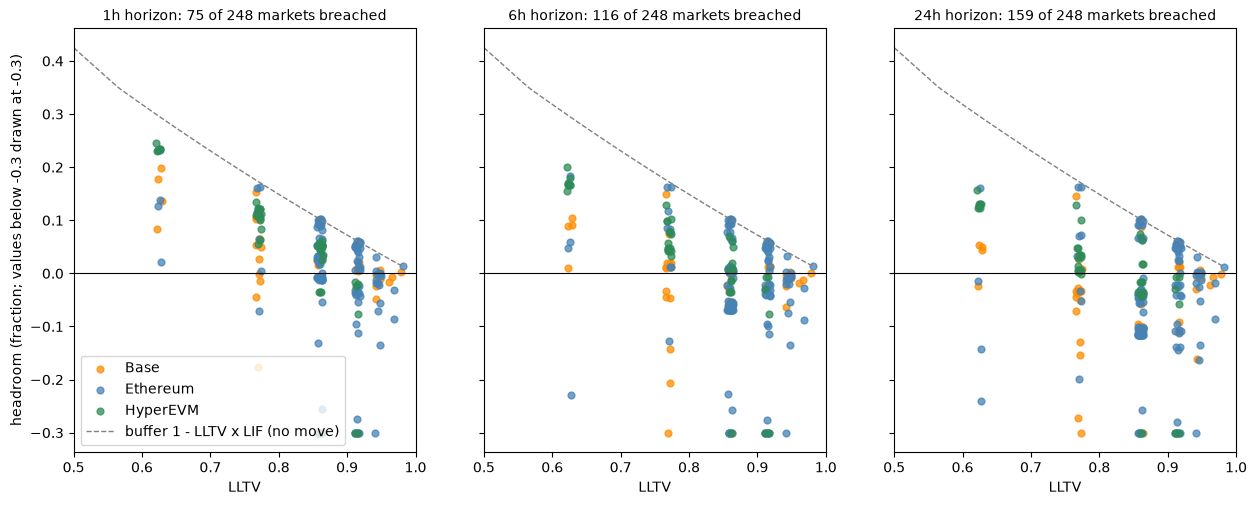

In [3]:
from myrmidons_api.protocol import bad_debt_buffer

colors = {"Ethereum": "steelblue", "Base": "darkorange", "HyperEVM": "seagreen"}
grid = np.linspace(0.5, 0.98, 100)
floor1 = -0.3
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True)
for ax, tau in zip(axes, HORIZONS, strict=True):
    okt = focus[focus[f"verdict_{tau}h"] != "no verdict"]
    for chain, g in okt.groupby("chain"):
        jitter = np.random.default_rng(0).uniform(-0.004, 0.004, len(g))
        ax.scatter(
            g.lltv + jitter,
            g[f"lltv_headroom_{tau}h"].clip(lower=floor1),
            s=24,
            alpha=0.75,
            color=colors[chain],
            label=chain,
        )
    ax.plot(
        grid,
        [bad_debt_buffer(x) for x in grid],
        "--",
        color="gray",
        lw=1,
        label="buffer 1 - LLTV x LIF (no move)",
    )
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlim(0.5, 1.0)
    ax.set_xlabel("LLTV")
    n_breached = int((okt[f"verdict_{tau}h"] == "breached").sum())
    ax.set_title(f"{tau}h horizon: {n_breached} of {len(okt)} markets breached", fontsize=10)
axes[0].set_ylabel(f"headroom (fraction; values below {floor1} drawn at {floor1})")
axes[0].legend(loc="lower left")
fig.savefig("assets/headroom_vs_lltv.png", dpi=150, bbox_inches="tight")

below = int((ok24.lltv_headroom_24h < floor1).sum())
print(
    f"{below} markets drawn at the floor at 24h (headroom below {floor1}): ",
    sorted(ok24[ok24.lltv_headroom_24h < floor1].pair.unique())[:20],
)

## Lane 2 — the horizon decides the verdict

The same market carries three verdicts, one per liquidation horizon. One hour is the latency of a liquidator on a liquid collateral with a working oracle; twenty-four hours is a liquidation that waits for capacity, for an oracle to update, or for a keeper to notice. The two horizons answer different questions, and the largest markets answer them differently.

248 markets carry all three verdicts
share of markets defensible, per horizon:
              1h     6h    24h
chain                        
Base      0.768  0.446  0.232
Ethereum  0.646  0.503  0.320
HyperEVM  0.778  0.733  0.644

87 markets are defensible at 1h and breached at 24h — $2,231M of borrow across the 63 listed ones
75 markets are breached even at 1h:  ['AVLT/USDC', 'AVLT/USD₮0', 'EIGEN/USDC', 'ETH+/WETH', 'KTA/USDC', 'LBTC/cbBTC', 'LsETH/USDC', 'LsETH/WETH', 'OETH/USDC', 'PT-cUSD-23JUL2026/USDT', 'PT-cUSD-29JAN2026/USDC', 'PT-cUSDO-20NOV2025/USDC', 'PT-hbUSDT-18DEC2025/USD₮0', 'PT-stcUSD-23JUL2026/USDT', 'PT-stcUSD-29JAN2026/USDC', 'RLP/AUSD', 'RLP/USDC', 'RLP/USR', 'SolvBTC/WBTC', 'TOSHI/USDC', 'USD0USD0++/USDC', 'USR/USDC', 'USUALX/USUAL', 'WBTC/LBTC', 'WETH/EURC']
   chain                   pair  lltv  lltv_headroom_1h  lltv_headroom_6h  lltv_headroom_24h  outstanding_borrow_usd
    Base             cbBTC/USDC 0.860            0.0510            0.0031            -0.0438 

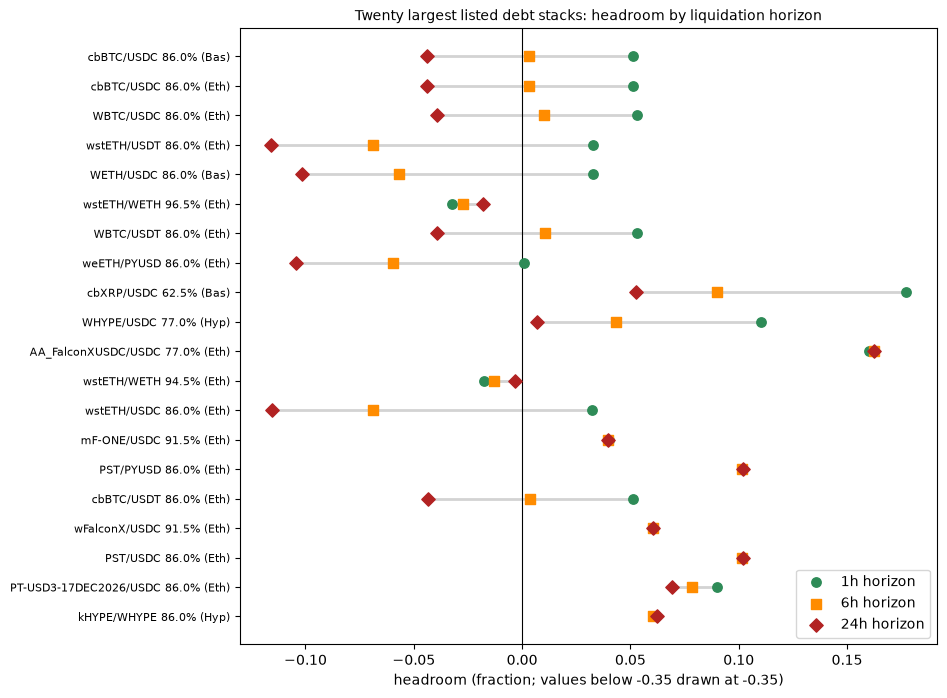

In [4]:
all3 = focus[(focus[[f"status_lltv_headroom_{t}h" for t in HORIZONS]] == "ok").all(axis=1)]
print(f"{len(all3)} markets carry all three verdicts")
share = pd.DataFrame(
    {
        f"{t}h": all3.groupby("chain")[f"verdict_{t}h"].apply(lambda s: (s == "defensible").mean())
        for t in HORIZONS
    }
)
print("share of markets defensible, per horizon:\n", share.round(3).to_string())

flip = all3[(all3.verdict_1h == "defensible") & (all3.verdict_24h == "breached")]
flip_listed = flip[flip.listed.fillna(False)]
print(
    f"\n{len(flip)} markets are defensible at 1h and breached at 24h — "
    f"${flip_listed.outstanding_borrow_usd.sum() / 1e6:,.0f}M of borrow "
    f"across the {len(flip_listed)} listed ones"
)
never = all3[all3.verdict_1h == "breached"]
print(f"{len(never)} markets are breached even at 1h: ", sorted(never.pair.unique())[:25])

# the twenty largest LISTED debt stacks (unlisted markets carry synthetic borrow figures)
top = (
    all3[all3.listed.fillna(False)]
    .dropna(subset=["outstanding_borrow_usd"])
    .nlargest(20, "outstanding_borrow_usd")
    .iloc[::-1]
)
fig, ax = plt.subplots(figsize=(9, 8))
y = np.arange(len(top))
floor = -0.35
for yi, row in zip(y, top.itertuples(), strict=True):
    lo = max(min(row.lltv_headroom_1h, row.lltv_headroom_6h, row.lltv_headroom_24h), floor)
    hi = max(row.lltv_headroom_1h, row.lltv_headroom_6h, row.lltv_headroom_24h)
    ax.plot([lo, hi], [yi, yi], color="lightgray", lw=2, zorder=1)
for tau, marker, col in [(1, "o", "seagreen"), (6, "s", "darkorange"), (24, "D", "firebrick")]:
    ax.scatter(
        top[f"lltv_headroom_{tau}h"].clip(lower=floor),
        y,
        marker=marker,
        s=46,
        color=col,
        label=f"{tau}h horizon",
        zorder=3,
    )
ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(y)
ax.set_yticklabels(
    [
        f"{pair} {lltv:.1%} ({chain[:3]})"
        for pair, lltv, chain in zip(top.pair, top.lltv, top.chain, strict=True)
    ],
    fontsize=8,
)
ax.set_xlabel(f"headroom (fraction; values below {floor} drawn at {floor})")
ax.set_title("Twenty largest listed debt stacks: headroom by liquidation horizon", fontsize=10)
ax.legend(loc="lower right")
fig.savefig("assets/headroom_by_horizon.png", dpi=150, bbox_inches="tight")
print(
    top[
        [
            "chain",
            "pair",
            "lltv",
            "lltv_headroom_1h",
            "lltv_headroom_6h",
            "lltv_headroom_24h",
            "outstanding_borrow_usd",
        ]
    ]
    .iloc[::-1]
    .round(4)
    .to_string(index=False)
)

## Lane 3 — one collateral, several LLTVs

Morpho Blue markets are permissionless, so the same collateral trades against the same loan asset at several LLTVs. The worst drop is a property of the pair; the buffer is a property of the tier. Where the pair's worst drop falls between two tiers' buffers, the history defends one tier and not the other.

25 pairs trade at two or more LLTVs; the 24h history splits the tiers on 6 of them:
   chain        pair          tiers defended_tiers  worst_simple_drop       borrow
    Base  cbXRP/USDC  [0.625, 0.77]        [0.625]             0.2430 4.664149e+07
    Base wstETH/WETH [0.945, 0.965]        [0.945]             0.0321 6.176771e+06
    Base  weETH/WETH [0.915, 0.945]        [0.915]             0.0488 1.702966e+06
HyperEVM  UBTC/USD₮0   [0.77, 0.86]         [0.77]             0.1382 1.146872e+06
HyperEVM   UBTC/USDe   [0.77, 0.86]         [0.77]             0.1391 2.522510e+05
HyperEVM  UETH/USD₮0   [0.77, 0.86]         [0.77]             0.1448 3.781650e+04

pairs where NO tier is defended at 24h: 9; all tiers defended: 10


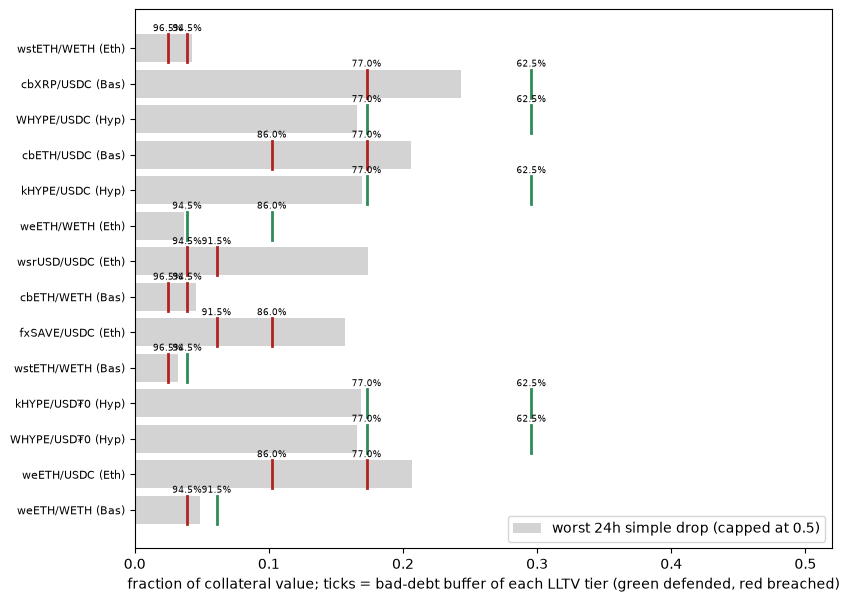

In [5]:
pairs = (
    ok24.groupby(["chain", "pair"])
    .agg(
        tiers=("lltv", lambda s: sorted(set(s.round(4)))),
        n_tiers=("lltv", "nunique"),
        worst_drop_24h=("worst_drop_24h", "first"),
        borrow=(
            "outstanding_borrow_usd",
            lambda s: s[ok24.loc[s.index, "listed"].fillna(False)].sum(),
        ),
    )
    .reset_index()
)
multi = pairs[pairs.n_tiers >= 2].copy()
multi["worst_simple_drop"] = 1 - np.exp(multi.worst_drop_24h)
multi["defended_tiers"] = multi.apply(
    lambda r: [t for t in r.tiers if bad_debt_buffer(t) > r.worst_simple_drop], axis=1
)
multi["split"] = multi.apply(lambda r: 0 < len(r.defended_tiers) < len(r.tiers), axis=1)
print(
    f"{len(multi)} pairs trade at two or more LLTVs; "
    f"the 24h history splits the tiers on {int(multi.split.sum())} of them:"
)
print(
    multi[multi.split]
    .sort_values("borrow", ascending=False)[
        ["chain", "pair", "tiers", "defended_tiers", "worst_simple_drop", "borrow"]
    ]
    .round(4)
    .to_string(index=False)
)
n_defended = multi.defended_tiers.map(len)
print(
    f"\npairs where NO tier is defended at 24h: {int((n_defended == 0).sum())}; "
    f"all tiers defended: {int((n_defended == multi.tiers.map(len)).sum())}"
)

show = multi.sort_values("borrow", ascending=False).head(14).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(show))
ax.barh(
    y,
    show.worst_simple_drop.clip(upper=0.5),
    color="lightgray",
    label="worst 24h simple drop (capped at 0.5)",
)
for yi, row in zip(y, show.itertuples(), strict=True):
    for t in row.tiers:
        b = bad_debt_buffer(t)
        ax.plot(
            [b, b],
            [yi - 0.4, yi + 0.4],
            color="seagreen" if b > row.worst_simple_drop else "firebrick",
            lw=2,
        )
        ax.annotate(f"{t:.1%}", (b, yi + 0.42), fontsize=6.5, ha="center", va="bottom")
ax.set_yticks(y)
ax.set_yticklabels(
    [f"{p} ({c[:3]})" for p, c in zip(show.pair, show.chain, strict=True)], fontsize=8
)
ax.set_xlabel(
    "fraction of collateral value; ticks = bad-debt buffer of each LLTV tier "
    "(green defended, red breached)"
)
ax.set_xlim(0, 0.52)
ax.legend(loc="lower right")
fig.savefig("assets/collateral_tiers.png", dpi=150, bbox_inches="tight")

## Lane 3b — the history-implied maximum LLTV per pair and horizon

Morpho Blue allows a fixed set of LLTVs (38.5%, 62.5%, 77%, 86%, 91.5%, 94.5%, 96.5%, 98%). For each pair and horizon, the highest allowed tier whose bad-debt buffer exceeds the pair's worst drop is the maximum LLTV the history defends. It is a property of the pair and of the horizon. The chain enters through the horizon a liquidation needs on that chain and through the liquidation costs (loop 03), which this run does not subtract.

199 pairs carry all three verdicts
pairs whose highest tier in use exceeds the history-implied maximum: {'1h': 63, '6h': 96, '24h': 129}

fifteen largest listed pairs:
   chain                pair          tiers  max_1h  max_6h  max_24h       borrow
    Base          cbBTC/USDC         [0.86]   0.915   0.860    0.770 1.390383e+09
Ethereum          cbBTC/USDC         [0.86]   0.915   0.860    0.770 3.062876e+08
Ethereum           WBTC/USDC         [0.86]   0.915   0.860    0.770 1.122978e+08
Ethereum         wstETH/WETH [0.945, 0.965]   0.915   0.915    0.915 1.066407e+08
Ethereum         wstETH/USDT         [0.86]   0.860   0.770    0.625 1.008660e+08
    Base           WETH/USDC         [0.86]   0.860   0.770    0.625 8.069359e+07
Ethereum           WBTC/USDT         [0.86]   0.915   0.860    0.770 7.226229e+07
Ethereum         weETH/PYUSD         [0.86]   0.860   0.770    0.625 5.919132e+07
    Base          cbXRP/USDC  [0.625, 0.77]   0.770   0.625    0.625 4.664149e+07
HyperEVM    

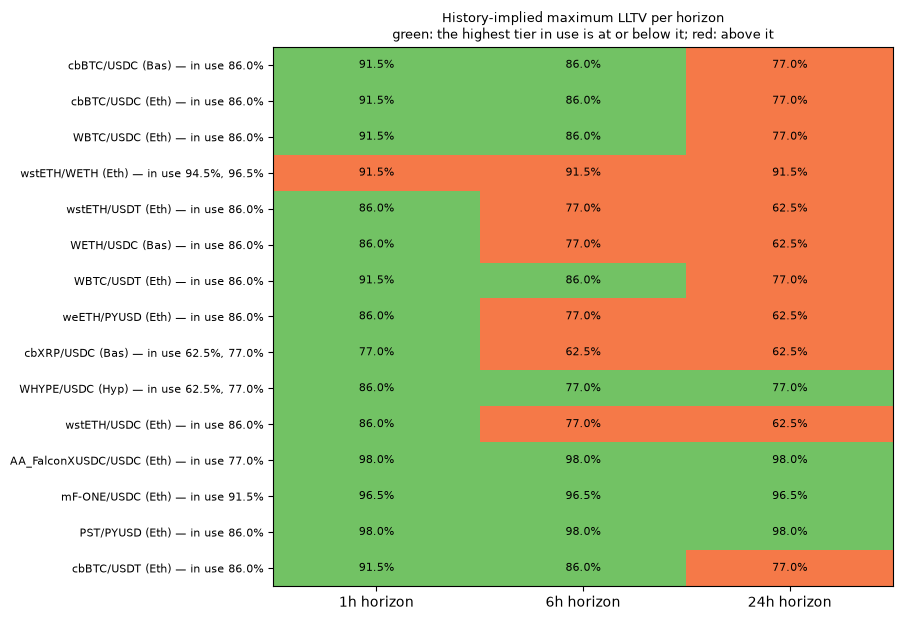

In [6]:
ALLOWED = (0.385, 0.625, 0.77, 0.86, 0.915, 0.945, 0.965, 0.98)


def max_tier(simple_drop):
    """Highest allowed LLTV whose bad-debt buffer exceeds the drop; NaN if none does."""
    ok = [t for t in ALLOWED if bad_debt_buffer(t) > simple_drop]
    return max(ok) if ok else np.nan


pair_h = (
    all3.groupby(["chain", "pair"])
    .agg(
        **{f"drop_{t}h": (f"worst_drop_{t}h", "first") for t in HORIZONS},
        tiers=("lltv", lambda s: sorted(set(s.round(4)))),
        borrow=(
            "outstanding_borrow_usd",
            lambda s: s[all3.loc[s.index, "listed"].fillna(False)].sum(),
        ),
    )
    .reset_index()
)
for t in HORIZONS:
    pair_h[f"max_{t}h"] = (1 - np.exp(pair_h[f"drop_{t}h"])).map(max_tier)
pair_h["top_tier"] = pair_h.tiers.map(max)
over = {f"{t}h": int((pair_h.top_tier > pair_h[f"max_{t}h"].fillna(0)).sum()) for t in HORIZONS}
print(f"{len(pair_h)} pairs carry all three verdicts")
print("pairs whose highest tier in use exceeds the history-implied maximum:", over)

show = pair_h[pair_h.borrow > 0].sort_values("borrow", ascending=False).head(15)
print("\nfifteen largest listed pairs:")
print(
    show[["chain", "pair", "tiers", "max_1h", "max_6h", "max_24h", "borrow"]]
    .round(4)
    .to_string(index=False)
)

fig, ax = plt.subplots(figsize=(8, 7))
mat = show[[f"max_{t}h" for t in HORIZONS]].to_numpy(dtype=float)
in_use = show.top_tier.to_numpy()
ax.imshow(
    np.where(mat >= in_use[:, None], 1.0, 0.0),
    cmap="RdYlGn",
    vmin=-0.4,
    vmax=1.4,
    aspect="auto",
)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        label = "none" if np.isnan(mat[i, j]) else f"{mat[i, j]:.1%}"
        ax.text(j, i, label, ha="center", va="center", fontsize=8)
ax.set_xticks(range(len(HORIZONS)))
ax.set_xticklabels([f"{t}h horizon" for t in HORIZONS])
ax.set_yticks(range(len(show)))
ax.set_yticklabels(
    [
        f"{p} ({c[:3]}) — in use {', '.join(f'{x:.1%}' for x in tiers)}"
        for p, c, tiers in zip(show.pair, show.chain, show.tiers, strict=True)
    ],
    fontsize=8,
)
ax.set_title(
    "History-implied maximum LLTV per horizon\n"
    "green: the highest tier in use is at or below it; red: above it",
    fontsize=9,
)
fig.savefig("assets/max_tier_by_horizon.png", dpi=150, bbox_inches="tight")

## Lane 4 — the curators' benchmark

Morpho Blue markets are permissionless. Anyone can create a market with one of the LLTVs the protocol allows, and anyone can supply to an existing market. A curator therefore chooses an LLTV when it creates a market and again when it funds one. The latest `vault_allocations` snapshot says which markets each vault supplies and how much. The curator behind each vault comes from the curator registry of the Morpho API (`vaults.state.curators` for V1 vaults, `vaultV2s.curators` for V2 vaults). The registry is fetched once and saved to `assets/vault_curators.csv`; a vault the registry does not name keeps the first word of its name as its label. The benchmark is the share of each curator's supplied value that sits in markets whose history has breached the bad-debt buffer, at 1h and at 24h. Supply is converted to USD with the loan asset's latest price.

curator registry: 217 tracked vaults named by the API; saved
vaults without a registry curator (label from the name): ['Growi USDC Core HyperEVM', 'MYRMIDONS USDC', 'MYRMIDONS USDT0', 'MYRMIDONS WHYPE', 'Test MYRMIDONS V2']
214 vaults, 40 curators, $4,335M supplied into collateral markets on the three chains
supply without a loan price (excluded from shares): 0 allocation rows
vault names whose first word differs from the curator:
                         vault_name                curator
            Moonwell Flagship EURC           Anthias Labs
            Moonwell Flagship USDC           Anthias Labs
             Moonwell Flagship ETH           Anthias Labs
           Moonwell Frontier cbBTC           Anthias Labs
                         Kabu WETH                   Api3
                      Purinta USDC                   Api3
                         Kabu USDC                   Api3
             Wintermute USDT Prime Armitage by Wintermute
            Wintermute USDC Select Armitag

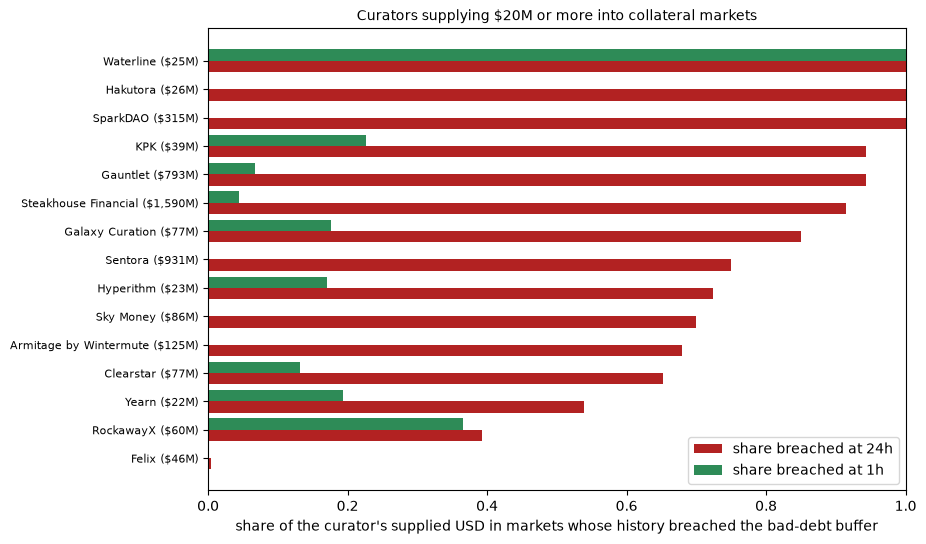

In [7]:
import urllib.request

alloc = r.sql(
    "WITH latest AS (SELECT chain_id, max(ts) AS ts FROM vault_allocations GROUP BY chain_id) "
    "SELECT a.chain_id, a.vault, a.market_id, a.supply_assets::DOUBLE AS supply_assets, "
    "v.name AS vault_name "
    "FROM vault_allocations a JOIN latest USING (chain_id, ts) "
    "LEFT JOIN vaults v USING (chain_id, vault) "
    "WHERE a.supply_assets > 0"
)
px = r.sql(
    "SELECT chain_id, token_address, price_usd FROM prices "
    "QUALIFY ROW_NUMBER() OVER (PARTITION BY chain_id, token_address ORDER BY ts DESC) = 1"
)

# curator registry: the Morpho API names the curator(s) behind each vault, V1 and V2
CURATORS_CSV = Path("assets/vault_curators.csv")
API = "https://api.morpho.org/graphql"
Q_V1 = (
    "query($c:[Int!],$first:Int!,$skip:Int!){ vaults(first:$first, skip:$skip, "
    "where:{chainId_in:$c}) { items { address state { curators { name } } } "
    "pageInfo { countTotal } } }"
)
Q_V2 = (
    "query($c:[Int!],$first:Int!,$skip:Int!){ vaultV2s(first:$first, skip:$skip, "
    "where:{chainId_in:$c}) { items { address curators { items { name } } } "
    "pageInfo { countTotal } } }"
)


def gql(query, variables):
    body = json.dumps({"query": query, "variables": variables}).encode()
    req = urllib.request.Request(API, data=body, headers={"content-type": "application/json"})
    out = json.load(urllib.request.urlopen(req, timeout=60))
    if "errors" in out:
        raise RuntimeError(out["errors"])
    return out["data"]


def fetch_curators():
    """(chain_id, vault) -> curator name(s), from both vault entities of the API."""
    found = {}
    specs = (
        (Q_V1, "vaults", lambda v: (v["state"] or {}).get("curators")),
        (Q_V2, "vaultV2s", lambda v: v["curators"]["items"]),
    )
    for query, entity, pick in specs:
        for chain in CHAINS:
            skip = 0
            while True:
                page = gql(query, {"c": [chain], "first": 100, "skip": skip})[entity]
                for v in page["items"]:
                    names = sorted({c["name"] for c in (pick(v) or [])})
                    if names:
                        found[(chain, v["address"].lower())] = " / ".join(names)
                skip += 100
                if skip >= page["pageInfo"]["countTotal"]:
                    break
    reg = pd.Series(found, name="curator").rename_axis(["chain_id", "vault"]).reset_index()
    return reg.merge(alloc[["chain_id", "vault"]].drop_duplicates())  # tracked vaults only


try:
    curators = fetch_curators()
    curators.to_csv(CURATORS_CSV, index=False)
    print(f"curator registry: {len(curators)} tracked vaults named by the API; saved")
except Exception as exc:  # offline: the committed registry
    curators = pd.read_csv(CURATORS_CSV)
    print(f"curator registry: API unavailable ({exc!r}); {len(curators)} vaults from the CSV")

a = (
    alloc.merge(
        sym[["chain_id", "market_id", "loan_token", "loan_decimals", "pair", "lltv", "listed"]],
        on=["chain_id", "market_id"],
        how="inner",
    )
    .merge(
        px.rename(columns={"token_address": "loan_token"}),
        on=["chain_id", "loan_token"],
        how="left",
    )
    .merge(curators, on=["chain_id", "vault"], how="left")
    .merge(
        h[["chain_id", "market_id", "verdict_1h", "verdict_24h", "lltv_headroom_24h"]],
        on=["chain_id", "market_id"],
        how="left",
    )
)
a = a[a.chain_id.isin(CHAINS)].copy()
a["supply_usd"] = a.supply_assets / 10.0 ** a.loan_decimals.astype(float) * a.price_usd
# a vault the registry does not name takes the first word of its name; when a registry
# curator starts with that word, the registry spelling is used (Steakhouse -> Steakhouse Financial)
by_first = {name.split()[0]: name for name in curators.curator.unique()}
a["first_word"] = a.vault_name.fillna("unknown").str.split().str[0]
unnamed = sorted(a[a.curator.isna()].vault_name.dropna().unique())
a["curator"] = a.curator.fillna(a.first_word.map(lambda w: by_first.get(w, w)))
print("vaults without a registry curator (label from the name):", unnamed)
print(
    f"{a.vault.nunique()} vaults, {a.curator.nunique()} curators, "
    f"${a.supply_usd.sum() / 1e6:,.0f}M supplied into collateral markets on the three chains"
)
print(
    "supply without a loan price (excluded from shares):",
    f"{a.supply_usd.isna().sum()} allocation rows",
)
print(
    "vault names whose first word differs from the curator:\n",
    a[a.first_word != a.curator][["vault_name", "curator"]]
    .drop_duplicates()
    .sort_values("curator")
    .to_string(index=False),
)


def bench(g):
    judged = g[g.verdict_24h.isin(["defensible", "breached"])]
    tot = judged.supply_usd.sum()
    return pd.Series(
        {
            "vaults": g.vault.nunique(),
            "markets": g.market_id.nunique(),
            "supplied_musd": g.supply_usd.sum() / 1e6,
            "judged_share": tot / g.supply_usd.sum() if g.supply_usd.sum() else np.nan,
            "breached_24h": judged.supply_usd[judged.verdict_24h == "breached"].sum() / tot
            if tot
            else np.nan,
            "breached_1h": judged.supply_usd[judged.verdict_1h == "breached"].sum() / tot
            if tot
            else np.nan,
        }
    )


cur = (
    a.groupby("curator")
    .apply(bench, include_groups=False)
    .sort_values("supplied_musd", ascending=False)
)
print("\nall curators:")
print(cur.round(3).to_string())
big = cur[cur.supplied_musd >= 20]

fig, ax = plt.subplots(figsize=(9, 6))
b2 = big.dropna(subset=["breached_24h"]).sort_values("breached_24h")
y = np.arange(len(b2))
ax.barh(y - 0.2, b2.breached_24h, height=0.4, color="firebrick", label="share breached at 24h")
ax.barh(y + 0.2, b2.breached_1h, height=0.4, color="seagreen", label="share breached at 1h")
ax.set_yticks(y)
ax.set_yticklabels(
    [f"{c} (${m:,.0f}M)" for c, m in zip(b2.index, b2.supplied_musd, strict=True)], fontsize=8
)
ax.set_xlabel(
    "share of the curator's supplied USD in markets whose history breached the bad-debt buffer"
)
ax.set_title("Curators supplying $20M or more into collateral markets", fontsize=10)
ax.set_xlim(0, 1)
ax.legend(loc="lower right")
fig.savefig("assets/curator_breach_share.png", dpi=150, bbox_inches="tight")

# disagreement: same pair, different tiers funded by different curators
dis = (
    a[a.verdict_24h.isin(["defensible", "breached"])]
    .groupby(["chain_id", "pair"])
    .agg(tiers=("lltv", "nunique"), curators=("curator", "nunique"), supplied=("supply_usd", "sum"))
    .reset_index()
)
dis = dis[(dis.tiers >= 2) & (dis.curators >= 2)].sort_values("supplied", ascending=False)
print(f"\n{len(dis)} pairs where two or more curators fund different LLTV tiers:")
for row in dis.head(10).itertuples():
    sub = a[(a.chain_id == row.chain_id) & (a.pair == row.pair)]
    tiers = (
        sub.groupby("lltv")
        .agg(
            curators=("curator", lambda s: sorted(set(s))),
            usd=("supply_usd", "sum"),
            verdict=("verdict_24h", "first"),
        )
        .reset_index()
    )
    print(
        f"  {CHAINS[row.chain_id]} {row.pair}: "
        + "; ".join(
            f"{t.lltv:.1%} {t.verdict} ${t.usd / 1e6:,.1f}M {t.curators}"
            for t in tiers.itertuples()
        )
    )

## Recomputability

One row rebuilt from the raw `prices` table and the row's own `params`: both legs, last price per hour, inner-joined; the declared cleaning rule; METRON `worst_window` at 24 samples; the api's `bad_debt_buffer`. The result must equal the stored row. The rebuild stops strictly before the cycle's end hour: the writer runs five minutes into the hour, before the ingestion's prices job has written that hour's sample, and a snapshot taken later holds it.

In [8]:
from metron import log_returns, worst_window
from myrmidons_api.orchestrators.market_metrics.lltv_headroom import drop_short_excursions

row = (
    ok24[(ok24.chain_id == 1) & ok24.listed.fillna(False)]
    .nlargest(1, "outstanding_borrow_usd")
    .iloc[0]
)
row_meta = fam[(fam.market_id == row.market_id) & (fam.metric == "lltv_headroom_24h")].iloc[0]
prm = json.loads(row_meta.params)
win = json.loads(row_meta.input_window)


def hourly_last(token):
    return r.sql(
        "SELECT CAST(date_trunc('hour', ts) AS TIMESTAMPTZ) AS ts_h, price_usd FROM prices "
        "WHERE chain_id = ? AND token_address = ? AND ts < ?::TIMESTAMPTZ AND price_usd >= ? "
        "QUALIFY ROW_NUMBER() OVER (PARTITION BY date_trunc('hour', ts) ORDER BY ts DESC) = 1 "
        "ORDER BY ts_h",
        [int(row.chain_id), token, win["end"], prm["min_price_usd"]],
    ).set_index("ts_h")["price_usd"]


cross = (hourly_last(row.collateral_token) / hourly_last(row.loan_token)).dropna().sort_index()
cross.index = pd.DatetimeIndex(cross.index).tz_convert("UTC")
cleaned = drop_short_excursions(
    cross,
    threshold=prm["spike_filter"]["threshold"],
    max_run=prm["spike_filter"]["max_run"],
    revert_tol=prm["spike_filter"]["revert_tol"],
)
assert len(cross) - len(cleaned) == prm["spikes_dropped"], (
    len(cross) - len(cleaned),
    prm["spikes_dropped"],
)
assert len(cleaned) == win["n_samples"], (len(cleaned), win["n_samples"])
worst = worst_window(log_returns(cleaned), prm["tau_h"]).cum_return
assert abs(worst - row.worst_drop_24h) < 1e-12, (worst, row.worst_drop_24h)
buffer = bad_debt_buffer(row.lltv)
assert abs(buffer - prm["buffer"]) < 1e-12
headroom = buffer - (1 - np.exp(worst))
assert abs(headroom - row.lltv_headroom_24h) < 1e-12, (headroom, row.lltv_headroom_24h)
print(
    f"{row.pair} ({CHAINS[row.chain_id]}, LLTV {row.lltv:.1%}): {len(cross)} hourly cross prices, "
    f"{prm['spikes_dropped']} dropped; worst 24h log return {worst:+.4f}, buffer {buffer:.4f}, "
    f"headroom {headroom:+.4f} — recomputed exactly from row metadata + raw inputs"
)

cbBTC/USDC (Ethereum, LLTV 86.0%): 14772 hourly cross prices, 0 dropped; worst 24h log return -0.1579, buffer 0.1023, headroom -0.0438 — recomputed exactly from row metadata + raw inputs
